# Omniscient Teacher
Below implements the Omniscient teacher from the Iterative Machine Teaching paper. 

First thing I've learnt is that I'm very rusty when it comes to programming, so it's been a good exercise to get back into the swing of things.

Secondly, I've realised that there isn't a method of transferring the bias in the paper. This is probably because who needs the bias? We can just make it part of the weight vector right? Well that's what I've done here. *Making a note of this as when I look at this in the future, that'll stump me for a while as to why I'm messing around with array indexing*

In [1]:
import numpy as np
import pylab as pl
import random

In [2]:
# Generates 2D data that is linearly separable - no overlap
def gen_lin_separable_data(n):
    # generate training data in the 2-d case
    mean1 = np.array([0, 0])
    mean2 = np.array([4, 4])
    cov = np.array([[0.8, -0.6], [-0.6, 0.8]])
    X1 = np.random.multivariate_normal(mean1, cov, (n//2))
    y1 = np.ones(len(X1))
    X2 = np.random.multivariate_normal(mean2, cov, (n//2))
    y2 = np.ones(len(X2)) * -1
    return X1, y1, X2, y2

In [5]:
def plot_margin(X1_train, X2_train, clf):
    def f(x, w, b, c=0):
        # given x, return y such that [x,y] in on the line
        # w.x + b = c
        return (-w[0][0] * x - b + c) / w[0][1]

    pl.plot(X1_train[:,0], X1_train[:,1], "ro", label="Class +1")
    pl.plot(X2_train[:,0], X2_train[:,1], "bo", label="Class -1")
    pl.scatter(clf.support_vectors_[:,1], clf.support_vectors_[:,2], s=100, c="g")

    # w.x + b = 0
    a0 = -5; a1 = f(a0, clf.coef_[:,1:], clf.intercept_)
    b0 = 5; b1 = f(b0, clf.coef_[:,1:], clf.intercept_)
    pl.plot([a0,b0], [a1,b1], "k")

    # w.x + b = 1
    a0 = -5; a1 = f(a0, clf.coef_[:,1:], clf.intercept_, 1)
    b0 = 5; b1 = f(b0, clf.coef_[:,1:], clf.intercept_, 1)
    pl.plot([a0,b0], [a1,b1], "k--")

    # w.x + b = -1
    a0 = -5; a1 = f(a0, clf.coef_[:,1:], clf.intercept_, -1)
    b0 = 5; b1 = f(b0, clf.coef_[:,1:], clf.intercept_, -1)
    pl.plot([a0,b0], [a1,b1], "k--")

    pl.xlabel('x1')
    pl.ylabel('x2')

    #pl.legend(numpoints=1)

    #pl.axis("tight")
    pl.show()

In [6]:
def plot_margin_bare(X1_train, X2_train, weights, bias):
    def f(x, w, b, c=0):
        # given x, return y such that [x,y] in on the line
        # w.x + b = c
        return (-w[0][0] * x - b + c) / w[0][1]

    pl.plot(X1_train[:,0], X1_train[:,1], "ro", label="Class +1")
    pl.plot(X2_train[:,0], X2_train[:,1], "bo", label="Class -1")

    # w.x + b = 0
    a0 = -5; a1 = f(a0, weights, bias)
    b0 = 5; b1 = f(b0, weights, bias)
    pl.plot([a0,b0], [a1,b1], "k")

    # w.x + b = 1
    a0 = -5; a1 = f(a0, weights, bias, 1)
    b0 = 5; b1 = f(b0, weights, bias, 1)
    pl.plot([a0,b0], [a1,b1], "k--")

    # w.x + b = -1
    a0 = -5; a1 = f(a0, weights, bias, -1)
    b0 = 5; b1 = f(b0, weights, bias, -1)
    pl.plot([a0,b0], [a1,b1], "k--")

    pl.xlabel('x1')
    pl.ylabel('x2')

    #pl.legend(numpoints=1)

    #pl.axis("tight")
    pl.show()

In [5]:
x1, y1, x2, y2 = gen_lin_separable_data(40)
l_sep = np.vstack((x1,x2))
lin_sep = np.ones((len(l_sep),len(l_sep[0])+1))
lin_sep[:,1:] = l_sep
Y = np.hstack((y1,y2))

In [8]:
from sklearn import svm
clf = svm.SVC()
clf.set_params(kernel='linear')
clf.fit(lin_sep, Y)
clf.intercept_

array([ 0.50710215])

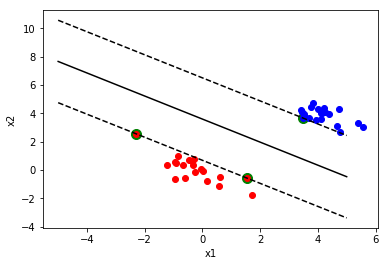

In [7]:
plot_margin(l_sep[Y==1], l_sep[Y==-1], clf)

Randomly initialize the studnet and teacher parameter $w^0$

In [8]:
studentW = np.array([random.random(), random.random(), random.random()])
teacherW = np.append(clf.intercept_, clf.coef_[:,1:])
studentW, teacherW, clf.intercept_

(array([ 0.40735675,  0.13696384,  0.38123112]),
 array([ 1.23671631, -0.2795454 , -0.34396812]),
 array([ 1.23671631]))

Set $t=1$ and the maximal iteration number $T$

In [9]:
t = 1
T = 50

while $w^t$ has not converged or $t\lt T$ do
Solve the optimization (e.g. pool based teaching) $$(x^t, y^t) = \min_{x\in X, y\in Y} \eta^2_t \| \frac{\partial \ell (\langle w^{t-1}, x \rangle , y)}{\partial w^{t-1}} \|^2 - 2 \eta _t \langle w^{t-1}-w^*,\frac{\partial \ell (\langle w^{t-1}, x^t \rangle , y)}{\partial w^{t-1}} \rangle $$
Use the selected example $(x^t,y^t)$ to perform the update $$w^t = w^{t-1}-\eta_t \frac{\partial \ell (\langle w^{t-1}, x^t \rangle, y^t)}{\partial w^{t-1}} $$
$t \leftarrow t + 1$
end while

In [35]:
def sq_loss(w, x, y):
    return 0.5*(np.dot(w, x) - y)**2

In [36]:
def der_sq_loss(w, x, y):
    return x * ((np.dot(w,x))-y)

In [37]:
def update_weight(w, learn_rate, x, y):
    return w - learn_rate * der_sq_loss(w, x, y)

In [38]:
def get_arg_min (w, X, Y, learn_rate, wS):
    minVal = (2**31)-1
    minInd = (2**31)-1
    for i in range(0, len(X)):
        p1 = learn_rate**2 * np.linalg.norm(der_sq_loss(w, X[i], Y[i]))**2
        p2 = 2*learn_rate*np.dot(w-wS, der_sq_loss(w, X[i], Y[i]))
        if (p1 - p2) < minVal:
            minVal = p1 - p2
            minInd = i
    return (X[minInd], Y[minInd])

In [14]:
get_arg_min(studentW, lin_sep, Y, 0.01, teacherW)

(array([ 1.        ,  3.84284981,  4.75758901]), -1.0)

In [15]:
while (not np.array_equal(studentW, teacherW) and t < T): 
    x, y = get_arg_min(studentW, lin_sep, Y, 0.001, teacherW)
    studentW = update_weight(studentW, 0.001, x, y)
    t +=1

In [16]:
studentW

array([ 0.3421409 , -0.13546341,  0.00381791])

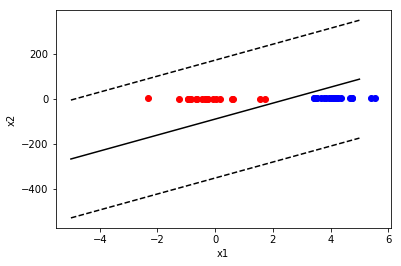

In [17]:
plot_margin_bare(l_sep[Y==1], l_sep[Y==-1], [studentW[1:]], studentW[0])

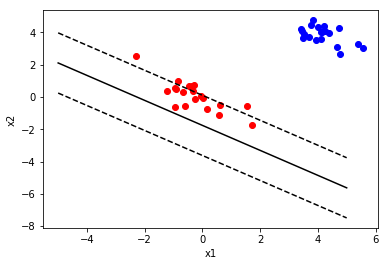

In [18]:
studentW = np.array([random.random(), random.random(), random.random()])
t = 1
T = 5
while (not np.array_equal(studentW, teacherW) and t < T): 
    x, y = get_arg_min(studentW, lin_sep, Y, 0.001, teacherW)
    studentW = update_weight(studentW, 0.001, x, y)
    t +=1
plot_margin_bare(l_sep[Y==1], l_sep[Y==-1], [studentW[1:]], studentW[0])

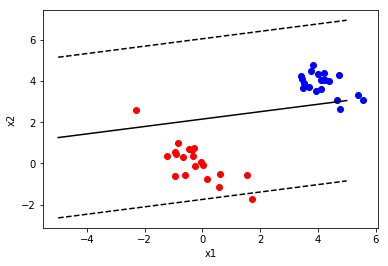

In [19]:
studentW = np.array([random.random(), random.random(), random.random()])
t = 1
T = 50
while (not np.array_equal(studentW, teacherW) and t < T): 
    x, y = get_arg_min(studentW, lin_sep, Y, 0.001, teacherW)
    studentW = update_weight(studentW, 0.001, x, y)
    t +=1
plot_margin_bare(l_sep[Y==1], l_sep[Y==-1], [studentW[1:]], studentW[0])

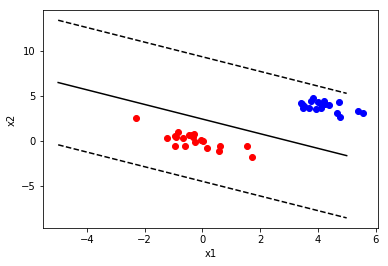

In [20]:
studentW = np.array([random.random(), random.random(), random.random()])
t = 1
T = 500
while (not np.array_equal(studentW, teacherW) and t < T): 
    x, y = get_arg_min(studentW, lin_sep, Y, 0.001, teacherW)
    studentW = update_weight(studentW, 0.001, x, y)
    t +=1
plot_margin_bare(l_sep[Y==1], l_sep[Y==-1], [studentW[1:]], studentW[0])

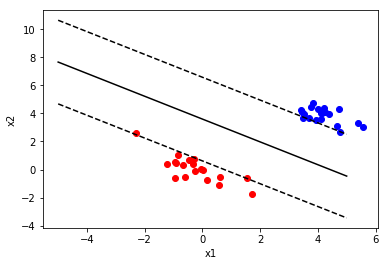

In [21]:
studentW = np.array([random.random(), random.random(), random.random()])
t = 1
T = 5000
while (not np.array_equal(studentW, teacherW) and t < T): 
    x, y = get_arg_min(studentW, lin_sep, Y, 0.001, teacherW)
    studentW = update_weight(studentW, 0.001, x, y)
    t +=1
plot_margin_bare(l_sep[Y==1], l_sep[Y==-1], [studentW[1:]], studentW[0])

In [22]:
studentW, teacherW

(array([ 1.20600861, -0.27265647, -0.33537253]),
 array([ 1.23671631, -0.2795454 , -0.34396812]))

Now let's try with overlapping data

In [26]:
def gen_lin_separable_overlap_data(n):
    mean1 = np.array([0, 1.5])
    mean2 = np.array([1.5, 0])
    cov = np.array([[1.5, 1.0], [1.0, 1.5]])
    X1 = np.random.multivariate_normal(mean1, cov, (n//2))
    y1 = np.ones(len(X1))
    X2 = np.random.multivariate_normal(mean2, cov, (n//2))
    y2 = np.ones(len(X2)) * -1
    return X1, y1, X2, y2

In [30]:
x1, y1, x2, y2 = gen_lin_separable_overlap_data(60)
l_sep = np.vstack((x1,x2))
lin_sep = np.ones((len(l_sep),len(l_sep[0])+1))
lin_sep[:,1:] = l_sep
Y = np.hstack((y1,y2))

In [31]:
clf = svm.SVC()
clf.set_params(kernel='linear')
clf.fit(lin_sep, Y)

SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma='auto', kernel='linear',
  max_iter=-1, probability=False, random_state=None, shrinking=True,
  tol=0.001, verbose=False)

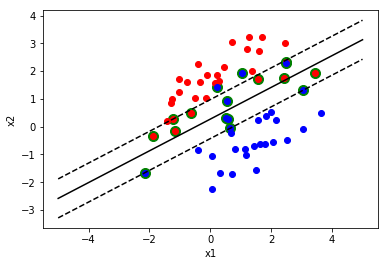

In [32]:
plot_margin(l_sep[Y==1], l_sep[Y==-1], clf)

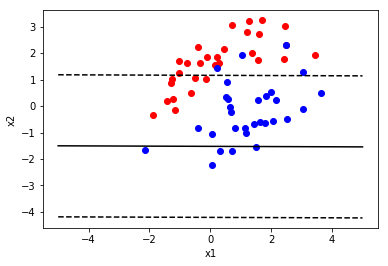

In [39]:
studentW = np.array([random.random(), random.random(), random.random()])
t = 1
T = 5
while (not np.array_equal(studentW, teacherW) and t < T): 
    x, y = get_arg_min(studentW, lin_sep, Y, 0.001, teacherW)
    studentW = update_weight(studentW, 0.001, x, y)
    t +=1
plot_margin_bare(l_sep[Y==1], l_sep[Y==-1], [studentW[1:]], studentW[0])

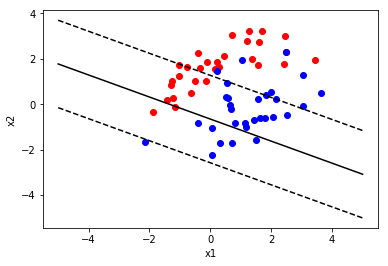

In [40]:
studentW = np.array([random.random(), random.random(), random.random()])
t = 1
T = 50
while (not np.array_equal(studentW, teacherW) and t < T): 
    x, y = get_arg_min(studentW, lin_sep, Y, 0.001, teacherW)
    studentW = update_weight(studentW, 0.001, x, y)
    t +=1
plot_margin_bare(l_sep[Y==1], l_sep[Y==-1], [studentW[1:]], studentW[0])

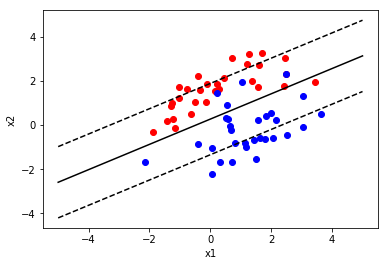

In [41]:
studentW = np.array([random.random(), random.random(), random.random()])
t = 1
T = 500
while (not np.array_equal(studentW, teacherW) and t < T): 
    x, y = get_arg_min(studentW, lin_sep, Y, 0.001, teacherW)
    studentW = update_weight(studentW, 0.001, x, y)
    t +=1
plot_margin_bare(l_sep[Y==1], l_sep[Y==-1], [studentW[1:]], studentW[0])

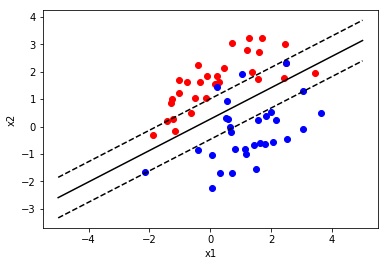

In [42]:
studentW = np.array([random.random(), random.random(), random.random()])
t = 1
T = 5000
while (not np.array_equal(studentW, teacherW) and t < T): 
    x, y = get_arg_min(studentW, lin_sep, Y, 0.001, teacherW)
    studentW = update_weight(studentW, 0.001, x, y)
    t +=1
plot_margin_bare(l_sep[Y==1], l_sep[Y==-1], [studentW[1:]], studentW[0])